100%|██████████| 12000/12000 [01:12<00:00, 166.06it/s]


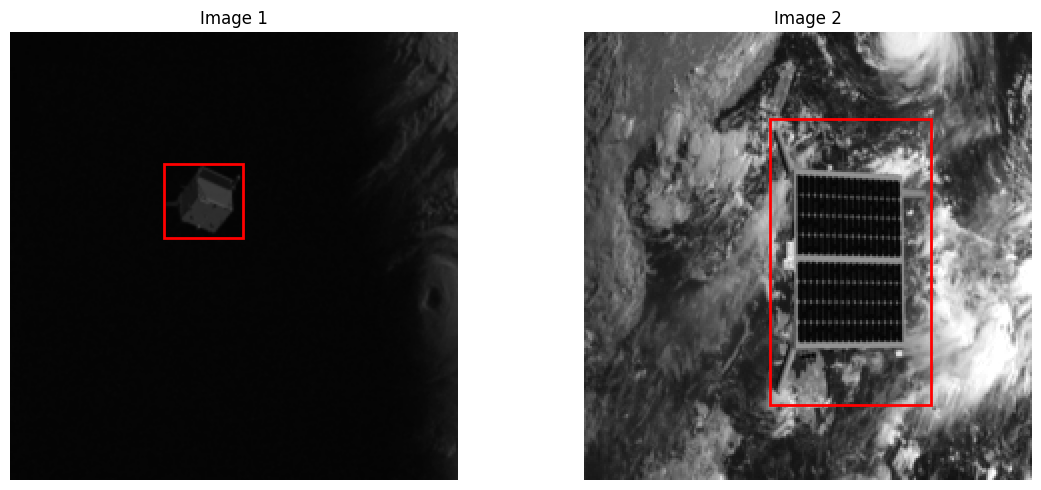

/tmp/ipykernel_19/4271655508.py:567: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Layer (type:depth-idx)                             Output Shape              Param #
SPN                                                [1, 5000]                 --
├─GeneralizedRCNNTransform: 1-1                    [1, 3, 224, 224]          --
├─Conv2d: 1-2                                      [1, 96, 54, 54]           (34,944)
├─MaxPool2d: 1-3                                   [1, 96, 26, 26]           --
├─LocalResponseNorm: 1-4                           [1, 96, 26, 26]           --
├─Conv2d: 1-5                                      [1, 256, 26, 26]          (307,456)
├─MaxPool2d: 1-6                                   [1, 256, 12, 12]          --
├─LocalResponseNorm: 1-7                           [1, 256, 12, 12]          --
├─Conv2d: 1-8                                      [1, 384, 12, 12]          (885,120)
├─Conv2d: 1-9                                      [1, 384, 12, 12]          (663,936)
├─Conv2d: 1-10                                     [1, 256, 12, 12]          (442,624)
├

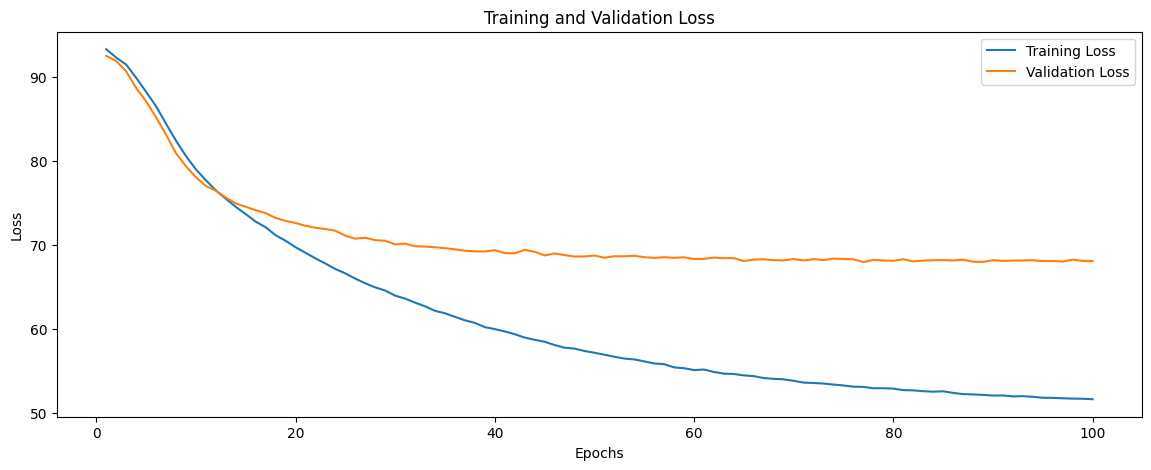

In [1]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn,optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models, ops
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.rpn import RegionProposalNetwork, RPNHead
from torchvision.models.detection.roi_heads import RoIHeads
from torchvision.models.detection.faster_rcnn import TwoMLPHead, FastRCNNPredictor
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchinfo import summary
from scipy.io import loadmat
from scipy.spatial.transform import Rotation as R
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import numpy as np
import tqdm



def get_discrete_classes(m):
    """
    Computes m uniformly distributed random rotations parametrized as unit quaternions.
    
    Args:
        m (int): Number of random rotations to generate
        
    Returns:
        numpy.ndarray: Matrix of shape (m, 4) containing unit quaternions
    """
    x0 = np.random.rand(m)
    x1 = np.random.rand(m)
    x2 = np.random.rand(m)
    
    
    theta1 = 2 * np.pi * x1
    theta2 = 2 * np.pi * x2
    
    
    s1 = np.sin(theta1)
    s2 = np.sin(theta2)
    c1 = np.cos(theta1)
    c2 = np.cos(theta2)
    
    
    r1 = np.sqrt(1 - x0)
    r2 = np.sqrt(x0)
    
    
    quats = np.column_stack([s1 * r1, c1 * r1, s2 * r2, c2 * r2])
    
    return quats

def _get_quat_bins(qPose, qClass, numNeighbors):
    ''' For each quaternion in `qPose`, find the nearest quaternion in `qClass` and
        the weights associated with distance to each class. Based on the original MATLAB 
        implementation by Sumant Sharma.
    Arguments:
        qPose:  (4,)  array of unit quaternion (scalar-first)
        qClass: (N,4) matrix of unit quaternion classes (scalar-first)
        numNeighbors: (int) number of `qClass` covering each of `qOise`
    Returns:
        nClasses: (numNeighbors,) array of closest quaternion classes
        nWeights: (numNeighbors,) array of weights of each quaternion classes
    '''
    # Quaternion classes into scalar-last for scipy
    q      = R.from_quat(qPose[[1,2,3,0]])
    qClass = R.from_quat(qClass[:,[1,2,3,0]])

    # Orientation diff. w.r.t. each entries in qClass [numClasses, 4]
    qDiff = q.inv() * qClass
    qDiff = qDiff.as_quat()

    # Angular distance w.r.t. each entries of qClass [rad]
    angleVec = 2 * np.arccos(np.abs(qDiff[:,-1])) # scalar-last

    # nAngles:  Smallest angular distances [rad]
    # nCLasses: Class indices of such entries
    sortIdx  = np.argsort(angleVec)
    nClasses = sortIdx[:numNeighbors]
    nAngles  = angleVec[nClasses]

    # Angular distances into weights
    nWeights = 1.0 - nAngles / np.pi**2 # (numNeighbors,)
    nWeights = nWeights / np.sum(nWeights)

    return nClasses, nWeights

def softmax_cross_entropy_with_logits(logits, target, reduction='mean'):
    """ Implementation of tensorflow's function of the same name
        - logits [B x C]
        - target [B x C]
    """
    loss = -torch.sum(target.detach() * F.log_softmax(logits, dim=1), dim=1) # [B,]
    if reduction == 'mean':
        return loss.mean()
    elif reduction == 'sum':
        return loss.sum()
    else:
        return loss

def load_tango_3d_keypoints(mat_dir):
    vertices  = loadmat(mat_dir)['tango3Dpoints'] # [3 x 11]
    corners3D = np.transpose(np.array(vertices, dtype=np.float32)) # [11 x 3]

    return corners3D

def load_camera_intrinsics(camera_json):
    with open(camera_json) as f:
        cam = json.load(f)
    cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
    distCoeffs   = np.array(cam['distCoeffs'],   dtype=np.float32)

    return cameraMatrix, distCoeffs

def quat2dcm(q):
    """ Computing direction cosine matrix from quaternion, adapted from PyNav.
    Arguments:
        q: (4,) numpy.ndarray - unit quaternion (scalar-first)
    Returns:
        dcm: (3,3) numpy.ndarray - corresponding DCM
    """

    # normalizing quaternion
    q = q/np.linalg.norm(q)

    q0 = q[0]
    q1 = q[1]
    q2 = q[2]
    q3 = q[3]

    dcm = np.zeros((3, 3))

    dcm[0, 0] = 2 * q0 ** 2 - 1 + 2 * q1 ** 2
    dcm[1, 1] = 2 * q0 ** 2 - 1 + 2 * q2 ** 2
    dcm[2, 2] = 2 * q0 ** 2 - 1 + 2 * q3 ** 2

    dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
    dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2

    dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
    dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1

    dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
    dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1

    return dcm

def project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
    ''' Project keypoints.
    Arguments:
        q_vbs2tango:  (4,) numpy.ndarray - unit quaternion from VBS to Tango frame
        r_Vo2To_vbs:  (3,) numpy.ndarray - position vector from VBS to Tango in VBS frame (m)
        cameraMatrix: (3,3) numpy.ndarray - camera intrinsics matrix
        distCoeffs:   (5,) numpy.ndarray - camera distortion coefficients in OpenCV convention
        keypoints:    (3,N) or (N,3) numpy.ndarray - 3D keypoint locations (m)
    Returns:
        points2D: (2,N) numpy.ndarray - projected points (pix)
    '''
    # Size check (3,N)
    if keypoints.shape[0] != 3:
        keypoints = np.transpose(keypoints)

    # Keypoints into 4 x N homogenous coordinates
    keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))

    # transformation to image frame
    pose_mat = np.hstack((np.transpose(quat2dcm(q_vbs2tango)),
                          np.expand_dims(r_Vo2To_vbs, 1)))
    xyz      = np.dot(pose_mat, keypoints) # [3 x N]
    x0, y0   = xyz[0,:] / xyz[2,:], xyz[1,:] / xyz[2,:] # [1 x N] each

    # apply distortion
    r2 = x0*x0 + y0*y0
    cdist = 1 + distCoeffs[0]*r2 + distCoeffs[1]*r2*r2 + distCoeffs[4]*r2*r2*r2
    x  = x0*cdist + distCoeffs[2]*2*x0*y0 + distCoeffs[3]*(r2 + 2*x0*x0)
    y  = y0*cdist + distCoeffs[2]*(r2 + 2*y0*y0) + distCoeffs[3]*2*x0*y0

    # apply camera matrix
    points2D = np.vstack((cameraMatrix[0,0]*x + cameraMatrix[0,2],
                          cameraMatrix[1,1]*y + cameraMatrix[1,2]))

    return points2D

class Speed(Dataset):
    def __init__(self, images_dir, json_dir, transform=None):
        self.images_dir = images_dir
        self.json_dir = json_dir
        self.transform = transform

        self.num_classes = 5000
        self.num_neighbors = 25

        self.imagesList = []
        self.yClassesList = []
        self.yWeightsList = []
        self.bboxList = []

        cnt=0

        # attClassesMAT =   get_discrete_classes(self.num_classes)
        attClassesMAT = loadmat('/kaggle/input/mat-file/attitudeClasses.mat')['qClass']
        keypts3d = load_tango_3d_keypoints('/kaggle/input/mat-file/tangoPoints.mat') # https://www.desmos.com/3d/jud6lng9gn
        cameraMatrix, distCoeffs = load_camera_intrinsics('/kaggle/input/mat-file/camera.json')

        with open(self.json_dir, 'r') as f:
            annotations = json.load(f)
            lookup = { item['filename']: item for item in annotations }


            for filename in tqdm.tqdm(os.listdir(self.images_dir)):
                if filename not in lookup:
                    continue
                self.imagesList.append(os.path.join(self.images_dir, filename))

                q_vbs2tango = np.array(lookup[filename]["q_vbs2tango"], dtype=np.float32)
                r_Vo2To_vbs = np.array(lookup[filename]['r_Vo2To_vbs_true'], dtype=np.float32)

                [attClasses, attWeights] = _get_quat_bins(q_vbs2tango, attClassesMAT, self.num_neighbors)

                yClasses = np.zeros(self.num_classes, dtype=np.float32)
                yClasses[attClasses] = 1. / self.num_neighbors

                yWeights = np.zeros(self.num_classes, dtype=np.float32)
                yWeights[attClasses] = attWeights

                self.yClassesList.append(torch.from_numpy(yClasses))
                self.yWeightsList.append(torch.from_numpy(yWeights))

                keypts2d = project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypts3d) # (2, 11)
                xmin = np.min(keypts2d[0])
                xmax = np.max(keypts2d[0])
                ymin = np.min(keypts2d[1])
                ymax = np.max(keypts2d[1])


                width = xmax - xmin
                height = ymax - ymin
                margin_x = width * 0.05
                margin_y = height * 0.05

                xmin = max(0, xmin - margin_x)
                xmax = xmax + margin_x
                ymin = max(0, ymin - margin_y)
                ymax = ymax + margin_y

                bbox = [xmin, xmax, ymin, ymax]

                self.bboxList.append(torch.tensor(bbox, dtype=torch.float32))

                cnt=cnt+1
                # if cnt>50:
                #     break

    def __len__(self):
        return len(self.imagesList)

    def __getitem__(self, idx):
        image_path = self.imagesList[idx]
        image = Image.open(image_path).convert('RGB')
        orig_w, orig_h = image.size
        yClasses = self.yClassesList[idx]
        yWeights = self.yWeightsList[idx]
        bbox = self.bboxList[idx]

        if self.transform:
            image = self.transform(image)
            new_h, new_w = image.shape[1], image.shape[2]
            scale_x = new_w / orig_w
            scale_y = new_h / orig_h

            xmin, xmax, ymin, ymax = bbox.tolist()
            xmin *= scale_x
            xmax *= scale_x
            ymin *= scale_y
            ymax *= scale_y
            bbox = torch.tensor([xmin, xmax, ymin, ymax], dtype=bbox.dtype, device=bbox.device)

        return image, yClasses, yWeights, bbox

transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
    ])

dataset = Speed(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', transform=transform)

train_size= int(0.8* len(dataset))
train_data, val_data = random_split(dataset, [train_size, len(dataset) - train_size])

num_images = min(2, len(dataset))
per_row = 2
rows = (num_images + per_row - 1) // per_row

plt.figure(figsize=(12, rows * 5))
for i in range(num_images):
    plt.subplot(rows, per_row, i + 1)
    image,_ , _,  bbox = dataset[i]
    xmin, xmax, ymin, ymax = bbox

    plt.imshow(image.permute(1, 2, 0))
    plt.gca().add_patch(
        plt.Rectangle((xmin, ymin),
                      xmax - xmin,
                      ymax - ymin,
                      fill=False,
                      edgecolor='red',
                      linewidth=2)
    )
    plt.title(f"Image {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

class SPN(nn.Module):
    def __init__(self, num_classes=5000, keep_prob=0.5, pretrain=True):
        super().__init__()

        self.num_classes = num_classes
        self.regress_size = self.num_classes
        self.keep_prob = keep_prob

        self.rpn_pre_nms_top_n_train = 500
        self.rpn_pre_nms_top_n_test = 250
        self.rpn_post_nms_top_n_train = 100
        self.rpn_post_nms_top_n_test = 1
        self.anchor_sizes   = ((32, 64, 128),)
        self.aspect_ratios  = ((0.5, 1.0, 2.0),)
        self.num_anchors = len(self.anchor_sizes[0]) * len(self.aspect_ratios[0])

        self.min_size = 224
        self.max_size = 224
        self.image_mean = [0.485, 0.456, 0.406]
        self.image_std = [0.229, 0.224, 0.225]

        self.transform = GeneralizedRCNNTransform(
            min_size=self.min_size,
            max_size=self.max_size,
            image_mean=self.image_mean,
            image_std=self.image_std
        )

        # 1st Layer: Conv (w ReLu) -> Pool -> Lrn
        self.conv1 = nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0) # Valid padding
        self.pool1 = nn.MaxPool2d(3, stride=2, padding=0)
        self.norm1 = nn.LocalResponseNorm(2, alpha=2e-5, beta=0.75, k=1.0)

        # 2nd Layer: Conv (w ReLu) -> Pool -> Lrn with 2 groups
        self.conv2 = nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2, groups=2)
        self.pool2 = nn.MaxPool2d(3, stride=2, padding=0)
        self.norm2 = nn.LocalResponseNorm(2, alpha=2e-5, beta=0.75, k=1.0)

        # 3rd Layer: Conv (w ReLU)
        self.conv3 = nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1)

        # 4th Layer: Conv (w ReLu) splitted into two groups
        self.conv4 = nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1, groups=2)

        # 5th Layer: Conv (w ReLu) -> Pool splitted into two groups
        self.conv5 = nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1, groups=2)
        self.pool5 = nn.MaxPool2d(3, stride=2, padding=0)

        self.rpn = RegionProposalNetwork(
                anchor_generator=AnchorGenerator(sizes=self.anchor_sizes, aspect_ratios=self.aspect_ratios),
                head=RPNHead(in_channels=256, num_anchors=self.num_anchors),
                fg_iou_thresh=0.7,
                bg_iou_thresh=0.3,
                batch_size_per_image=128,
                positive_fraction=0.5,
                pre_nms_top_n=dict(training=self.rpn_pre_nms_top_n_train, testing=self.rpn_pre_nms_top_n_test),
                post_nms_top_n=dict(training=self.rpn_post_nms_top_n_train, testing=self.rpn_post_nms_top_n_test),
                nms_thresh=0.7,
                score_thresh=0.0,
        )

        self.roi_heads = RoIHeads(
                    box_roi_pool=ops.MultiScaleRoIAlign(featmap_names=['0'], output_size=(6, 6), sampling_ratio=2),
                    box_head=TwoMLPHead(in_channels=256 * 6 * 6, representation_size=1024),
                    box_predictor=FastRCNNPredictor(in_channels=1024, num_classes=2),
                    fg_iou_thresh=0.5,
                    bg_iou_thresh=0.5,
                    batch_size_per_image=64,
                    positive_fraction=0.25,
                    bbox_reg_weights=None,
                    score_thresh=0.05,
                    nms_thresh=0.5,
                    detections_per_img=100,
                )
        
        # Additional convolutional layers after RoI pooling
        self.post_roi_conv1 = nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1)
        self.post_roi_bn1 = nn.BatchNorm2d(384)
        
        self.post_roi_conv2 = nn.Conv2d(384, 512, kernel_size=3, stride=1, padding=1)
        self.post_roi_bn2 = nn.BatchNorm2d(512)
        
        self.post_roi_conv3 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=0)
        self.post_roi_bn3 = nn.BatchNorm2d(512)
        
        # Calculate new feature size after convolutions
        # Original size: 6x6x256
        # After post_roi_conv1: 6x6x384
        # After post_roi_conv2: 6x6x512
        # After post_roi_conv3: 4x4x512
        self.roi_pool_size = 512 * 4 * 4

        # 6th Layer: Flatten -> FC (w ReLu) -> Dropout
        self.fc6 = nn.Linear(self.roi_pool_size, 4096)
        self.dropout6 = nn.Dropout(p=self.keep_prob, inplace=False)

        # 7th Layer: FC (w ReLu) -> Dropout
        self.fc7 = nn.Linear(4096, 4096)
        self.dropout7 = nn.Dropout(p=self.keep_prob, inplace=False)

        # 8th Layer: FC (no ReLu), return unscaled activations (for tf.nn.softmax_cross_entropy_with_logits)
        self.fc8 = nn.Linear(4096, self.num_classes)

        # 9th Layer: Flatten -> FC (w ReLu) -> Dropout
        self.fc9 = nn.Linear(self.roi_pool_size, 4096)
        self.dropout9 = nn.Dropout(p=self.keep_prob, inplace=False)

        # 10th Layer: FC (w ReLu) -> Dropout
        self.fc10 = nn.Linear(4096, 4096)
        self.dropout10 = nn.Dropout(p=self.keep_prob, inplace=False)

        # 11th Layer: FC (no ReLu), return unscaled activations
        self.fc11 = nn.Linear(4096, self.regress_size)


        if pretrain:
            state_dict = torch.load("/kaggle/input/spnrpn/epoch_100_model_weights.pth", map_location=device)
            self.load_state_dict(state_dict, strict=False)

    def forward(self, X, targets=None):

        images, targets = self.transform(X, targets)

        x = self.norm1(self.pool1(F.relu(self.conv1(images.tensors))))
        x = self.norm2(self.pool2(F.relu(self.conv2(x))))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        conv_features = self.pool5(F.relu(self.conv5(x)))

        features = {'0': conv_features}

        #RPN
        proposals, proposal_losses = self.rpn(images, features, targets=targets)
        detections, detector_losses = self.roi_heads(features, proposals, images.image_sizes, targets=targets)

        boxes_list = [det['boxes'] for det in detections]
        if len(boxes_list) == 0 or all(b.shape[0] == 0 for b in boxes_list):
            if targets is None:
                default_boxes = []
                for i, img_size in enumerate(images.image_sizes):
                    h, w = img_size
                    default_box = torch.tensor([[0, 0, w, h]], 
                                              device=X.device, 
                                              dtype=torch.float32)
                    default_boxes.append(default_box)
                boxes_list = default_boxes
            else:
                boxes_list = [t['boxes'] for t in targets]

        pooled = self.roi_heads.box_roi_pool(
        features,
        boxes_list,
        images.image_sizes,
        )
        
        # Apply additional convolutional layers to pooled features
        pooled = F.relu(self.post_roi_bn1(self.post_roi_conv1(pooled)))
        pooled = F.relu(self.post_roi_bn2(self.post_roi_conv2(pooled)))
        pooled = F.relu(self.post_roi_bn3(self.post_roi_conv3(pooled)))
        
        # Now flatten the processed features
        pooled_features = pooled.flatten(start_dim=1)

        # Record number of pooled ROIs per image
        roi_counts = [boxes.shape[0] for boxes in boxes_list]

        # Attitude classification
        c = self.dropout6(F.relu(self.fc6(pooled_features)))
        c = self.dropout7(F.relu(self.fc7(c)))
        c = self.fc8(c)

        # Attitude regression
        r = self.dropout9(F.relu(self.fc9(pooled_features)))
        r = self.dropout10(F.relu(self.fc10(r)))
        r = self.fc11(r)

        return c, r, roi_counts, detections

def train_loop(train_dataloader,val_dataloader,model,loss_fn,optimizer,batch_size,epoch):
    train_size = len(train_dataloader.dataset)
    num_batches = len(train_dataloader)
    loss_tot = 0
    for batch,(X,yClasses, yWeights, yBbox) in enumerate(train_dataloader):
        X, yClasses, yWeights, yBbox = X.to(device), yClasses.to(device), yWeights.to(device), yBbox.to(device)
        model.train()
        targets = []
        for i in range(len(X)):
            box = torch.tensor([yBbox[i][0], yBbox[i][2], yBbox[i][1], yBbox[i][3]], device=device).view(1, 4)
            target = {'boxes': box, 'labels': torch.ones(1, dtype=torch.int64, device=device)}
            targets.append(target)
        optimizer.zero_grad()

        
        with autocast("cuda"):
            classes, weights, roi_counts, detections = model(X, targets)
            yC_list, yW_list = [], []
            for i, cnt in enumerate(roi_counts):
                yC_list.append(yClasses[i].unsqueeze(0).expand(cnt, -1))
                yW_list.append(yWeights[i].unsqueeze(0).expand(cnt, -1))
            yC_exp = torch.cat(yC_list, dim=0)
            yW_exp = torch.cat(yW_list, dim=0)
            loss_class = loss_fn(classes, yC_exp)
            loss_regress = loss_fn(weights, yW_exp)
            loss = loss_class + 10.0 * loss_regress

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()  

        loss_tot += loss.item()

        current = batch * batch_size + len(X)
        print(f"\rEpoch {epoch+1} : Training loss: {loss:>7f}  [{current:>5d}/{train_size:>5d}]", end="")

    loss_avg = loss_tot / num_batches
    val_loss = 0
    model.eval()
    with torch.no_grad():
        for batch, (X, yClasses, yWeights, yBbox) in enumerate(val_dataloader):
            X, yClasses, yWeights, yBbox = X.to(device), yClasses.to(device), yWeights.to(device), yBbox.to(device)
            targets = []
            for i in range(len(X)):
                box = torch.tensor([yBbox[i][0], yBbox[i][2], yBbox[i][1], yBbox[i][3]], device=device).view(1, 4)
                target = {'boxes': box, 'labels': torch.ones(1, dtype=torch.int64, device=device)}
                targets.append(target)
            with autocast("cuda"):
                classes, weights, roi_counts, detections = model(X, targets)
            yClasses_list = []
            yWeights_list = []
            for i, count in enumerate(roi_counts):
                yClasses_list.append(yClasses[i].unsqueeze(0).expand(count, -1))
                yWeights_list.append(yWeights[i].unsqueeze(0).expand(count, -1))
            yClasses_expanded = torch.cat(yClasses_list, dim=0)
            yWeights_expanded = torch.cat(yWeights_list, dim=0)
            loss_cls = loss_fn(classes, yClasses_expanded)
            loss_reg = loss_fn(weights, yWeights_expanded)
            # print(f"Classification Loss: {loss_cls.item():.4f}, Regression Loss: {loss_reg.item():.4f}")
            val_loss += (loss_cls + 10.0 * loss_reg).item()
    val_loss /= len(val_dataloader)
    print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Validation loss: {val_loss:>7f}")
    print(end='')
    return loss_avg, val_loss


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()
model=SPN().to(device)

learning_rate = 3e-3
batch_size = 16
epochs = 100
loss_fn = softmax_cross_entropy_with_logits

for name, param in model.named_parameters():
    if not any(head in name for head in ('fc6','fc7','fc8','fc9','fc10','fc11')):
        param.requires_grad = False
        
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.95)

train_dataloader = DataLoader(train_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)
validation_dataloader = DataLoader(val_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)


loss_history = {'train': [], 'val': []}

best_val_loss = float('inf')
patience = 100  # How many epochs to wait after last improvement
patience_counter = 0
min_delta=0.001

print(summary(model, (1,3,224,224)))


for t in range(epochs):
    print(f"Epoch {t+1}", end=" ")
    train_loss, val_loss = train_loop(train_dataloader, validation_dataloader, model, loss_fn, optimizer, batch_size, t)
    loss_history['train'].append(train_loss)
    loss_history['val'].append(val_loss)

    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        patience_counter = 0  
        torch.save(model.state_dict(), 'best_model_weights_classes.pth')
    else:
        patience_counter += 1 
    
    if (t + 1) % 5 == 0:
        torch.save(model.state_dict(), f'epoch_{t+1}_model_weights.pth')
        
    if patience_counter >= patience:
        print(f"\nStopping early at epoch {t+1} with restoring best weights")
        epochs = t+1
        break


plt.figure(figsize=(14, 5))
eplist=[]
for i in range(epochs):
    eplist.append(i+1)
plt.plot(eplist, loss_history['train'], label='Training Loss')
plt.plot(eplist, loss_history['val'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()